In [ ]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate classification dataset
X, y = make_classification(
    n_samples=1000,         # total number of samples
    n_features=10,          # total number of features
    n_informative=5,        # number of informative features
    n_redundant=2,          # number of redundant features
    n_repeated=0,           # repeated features
    n_classes=2,            # binary classification
    n_clusters_per_class=1,
    weights=None,           # balanced classes
    flip_y=0.01,            # small label noise
    class_sep=1.5,          # higher means easier to separate
    random_state=42         # reproducibility
)

# Convert to pandas DataFrame
df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(X.shape[1])])
df['target'] = y




In [ ]:
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
0,2.391920,0.611154,2.056545,-0.767381,1.648846,1.992141,2.111632,-1.334854,-2.426075,-0.077773,0
1,1.607854,1.454373,0.946662,0.902533,2.405526,-1.313787,1.759474,1.935686,1.559668,-1.131406,1
2,-0.895996,1.827179,-0.188502,-1.359969,1.954482,1.707164,0.560198,-2.451932,-2.566753,1.227800,0
3,1.587328,0.119921,2.232550,0.957234,1.339760,2.122668,-0.582722,-2.849058,-3.357191,-0.582887,0
4,0.592534,0.414747,1.026122,-0.117240,2.080351,-0.788508,2.425246,0.224545,-0.137229,0.733348,1
...,...,...,...,...,...,...,...,...,...,...,...
995,-0.279353,-2.401416,2.324630,-0.003506,0.319196,-1.416715,-0.025467,-0.591746,-0.549122,-0.415045,1
996,0.412981,1.851417,0.342138,-0.292955,2.023047,1.379694,0.193296,-1.638564,-1.848628,-2.619152,0
997,0.706485,0.085571,1.731319,1.118183,1.786036,-2.189423,1.784459,2.581972,2.182187,1.198643,1
998,0.360986,-1.811846,3.033898,-1.611169,0.482782,1.551311,3.060476,-1.648743,-2.914413,2.114415,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1],random_state =  12, test_size =  0.3 , stratify = df.iloc[:,-1])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
tree=DecisionTreeClassifier()
params  = {
    "max_depth" :[3,4,5,6,7,8,None],
    "criterion" : ["gini","entropy","log_loss"],
    "splitter" :["best" , "random"]


}
grid = GridSearchCV(estimator =  tree  , cv = 5 , param_grid = params , n_jobs = -1 , scoring = "accuracy")


In [ ]:
grid.fit(x_train , y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 4, 5, 6, 7, 8, None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [ ]:
grid.best_params_
from sklearn.metrics import classification_report

In [ ]:
clf=DecisionTreeClassifier(criterion=  'entropy' ,max_depth= 5,splitter =  'best')
clf.fit(x_train , y_train)
print(classification_report(y_test,clf.predict(x_test)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       150
           1       0.99      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



[Text(0.5416666666666666, 0.9, 'x[5] <= 0.148\nentropy = 1.0\nsamples = 700\nvalue = [350, 350]'),
 Text(0.3333333333333333, 0.7, 'x[7] <= -2.724\nentropy = 0.126\nsamples = 348\nvalue = [6, 342]'),
 Text(0.4375, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'x[4] <= 2.074\nentropy = 0.65\nsamples = 6\nvalue = [5, 1]'),
 Text(0.08333333333333333, 0.3, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.25, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.5, 'x[6] <= -0.182\nentropy = 0.029\nsamples = 342\nvalue = [1, 341]'),
 Text(0.4166666666666667, 0.3, 'x[6] <= -0.241\nentropy = 0.391\nsamples = 13\nvalue = [1, 12]'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5833333333333334, 0.3, 'entropy = 0.0\nsamples = 329\nvalue = [0, 329]'),
 Text(0.75, 0.7, 'x[4] <= 2.747\nentropy = 0.156\nsamples = 352\nvalue = [344, 8]'),
 Text(0.6458333333333333, 0.8, '  False'

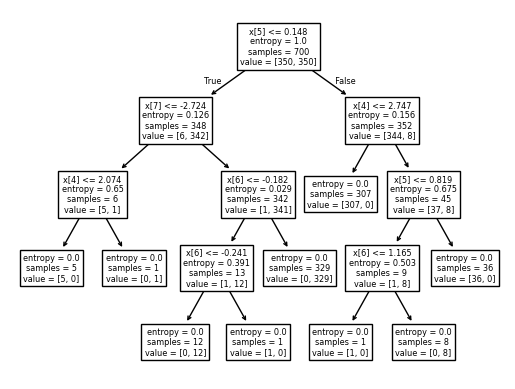

In [ ]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [ ]:
!pip install dtreeviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
from dtreeviz import model as tree_plot

In [ ]:
viz= tree_plot(model = clf  ,X_train = x_train.to_numpy()  ,y_train = y_train.to_numpy()  , feature_names = df.columns[:-1] ,class_names=[0,1] ,target_name  = "target")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


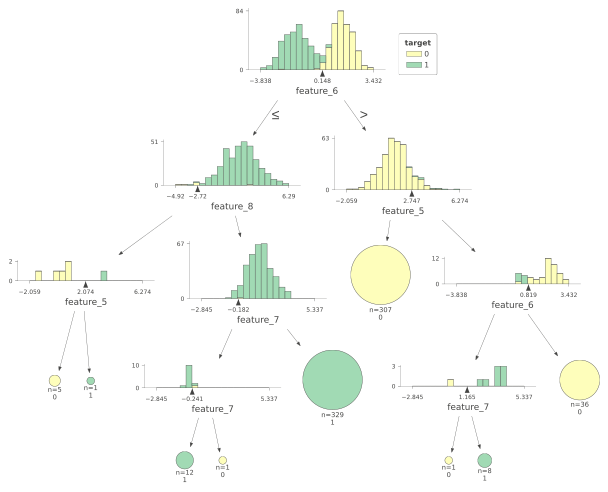

In [ ]:
viz.view()

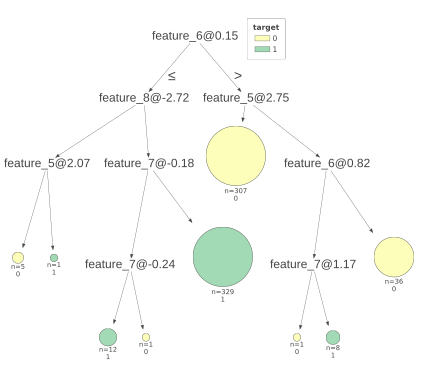

In [ ]:
viz.view(fancy=False)

/usr/local/lib/python3.11/dist-packages/dtreeviz/models/shadow_decision_tree.py:335: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/usr/local/lib/python3.11/dist-packages/dtreeviz/trees.py:1231: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


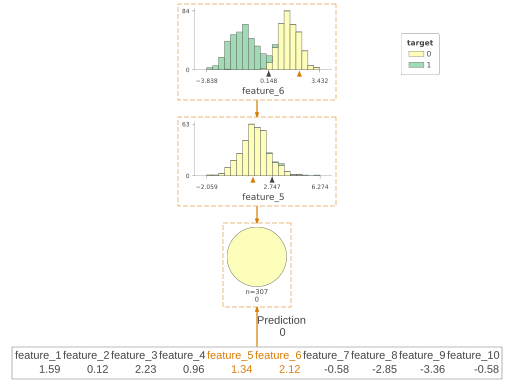

In [ ]:
# viz.view(orientation = "LR")
t =df.iloc[3,:-1]
viz.view(x=t,show_just_path = True)

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# BAGGING USING DECISION TREES

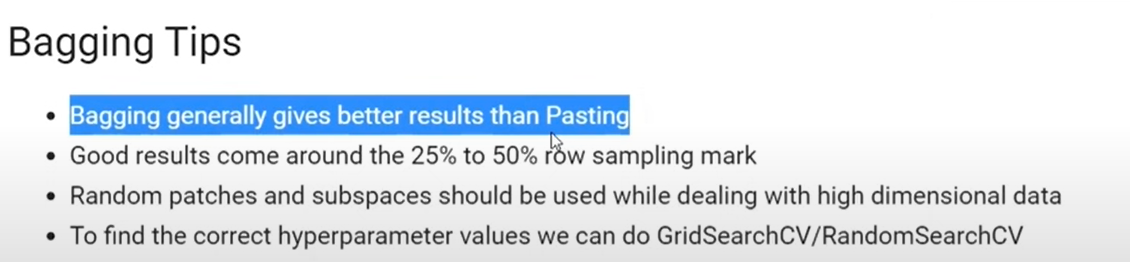

In [ ]:

bag =BaggingClassifier(estimator=DecisionTreeClassifier(),max_samples = 0.4 , n_estimators = 200 , bootstrap = True , oob_score = True ,n_jobs = -1)
bag.fit(x_train , y_train)
bag.score(x_test , y_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test , bag.predict(x_test))


# BAGGING USING KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
bag =BaggingClassifier(estimator=KNeighborsClassifier(),max_samples = 0.4 , n_estimators = 200 , bootstrap = True , oob_score = True ,n_jobs = -1)
bag.fit(x_train , y_train)
bag.score(x_test , y_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test , bag.predict(x_test))


0.9933333333333333

# PASTING  : USING LOGISTIC REGRESSION

In [ ]:
#boots trap = False
bag =BaggingClassifier(estimator=LogisticRegression(),max_samples = 0.4 ,bootstrap =False, n_estimators = 200 ,n_jobs = -1)
bag.fit(x_train , y_train)
bag.score(x_test , y_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test , bag.predict(x_test))


0.9966666666666667

# RANDOM SUB-SPACES

In [ ]:
# sampling across features
bag =BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators = 200,max_samples =1
                       ,max_features=0.4, bootstrap_features= True, bootstrap = False  ,n_jobs = -1)
bag.fit(x_train , y_train)
bag.score(x_test , y_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test , bag.predict(x_test))


0.5

# RANDOM PATCHES

In [ ]:
# sampling across features and rows
bag =BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators = 200,max_samples =0.45
                       ,max_features=0.4, bootstrap_features= True, bootstrap = True  ,n_jobs = -1)
bag.fit(x_train , y_train)
bag.score(x_test , y_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test , bag.predict(x_test))


0.9866666666666667

# BAGGING REGRESSOR

In [ ]:
from sklearn.datasets import make_regression
import pandas as pd

X, y = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=7,
    noise=10.0,
    bias=5.0,
    random_state=42
)

# Convert to DataFrame (optional, for viewing)
df = pd.DataFrame(X, columns=[f"feature_{i+1}" for i in range(X.shape[1])])
df["target"] = y

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
bag_reg = BaggingRegressor(estimator  = DecisionTreeRegressor() , n_estimators = 400 , n_jobs = -1 ,max_samples=0.4)

In [ ]:
bag_reg.fit(X_train,y_train)
bag_reg.score(X_test , y_test)

0.8756007768584957

In [ ]:
bag_reg.estimators_[0]

DecisionTreeRegressor(random_state=1145682156)

In [ ]:
import dtreeviz
from dtreeviz import model as plotter

In [ ]:
viz  = plotter(model  = bag_reg.estimators_[0] , X_train= X_train, y_train = y_train , feature_names =  df.columns[:-1],target_name="target" )